**Environment Setup**

In [2]:
!git clone https://github.com/chouyunming/interview-assignment.git

Cloning into 'interview-assignment'...
remote: Enumerating objects: 25036, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 25036 (delta 3), reused 8 (delta 2), pack-reused 25024 (from 3)
Receiving objects: 100% (25036/25036), 541.51 MiB | 37.47 MiB/s, done.
Resolving deltas: 100% (4/4), done.
Updating files: 100% (25012/25012), done.


In [3]:
%cd interview-assignment

/content/interview-assignment


In [ ]:
!pip install -r requirements.txt

**Preparing Dataset**

In [26]:
!unzip -q data/train.zip -d data/

In [27]:
# Since test1 doesn't have ground truth, 2500 images each from the data/train datasets (dogs and cats) were used as the testing set.
!mkdir -p data/test
# Using Linux command is more convinient!
!ls data/train/cat.* | shuf -n 2500 | xargs -I{} mv {} data/test/
!ls data/train/dog.* | shuf -n 2500 | xargs -I{} mv {} data/test/

In [28]:
# Prepare validation set split from the rest of training data (2000 images each for dogs and cats)
!mkdir -p data/val
!ls data/train/cat.* | shuf -n 2000 | xargs -I{} mv {} data/val/
!ls data/train/dog.* | shuf -n 2000 | xargs -I{} mv {} data/val/

In [29]:
import os

data_dirs = {
    'Train': 'data/train',
    'Validation': 'data/val',
    'Test': 'data/test'
}

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

for name, path in data_dirs.items():
  if os.path.exists(path):
      files = os.listdir(path)
      total = len(files)

      # Count cats and dogs
      cats = sum(1 for f in files if f.startswith('cat.'))
      dogs = sum(1 for f in files if f.startswith('dog.'))

      print(f"\n{name} ({path})")
      print(f"Total images: {total}")
      print(f"Cats: {cats}")
      print(f"Dogs: {dogs}")
  else:
      print(f"\n{name} ({path})")
      print(f"⚠ Directory not found")

print("\n" + "=" * 70)

DATASET INFORMATION

Train (data/train)
Total images: 16000
Cats: 8000
Dogs: 8000

Validation (data/val)
Total images: 4000
Cats: 2000
Dogs: 2000

Test (data/test)
Total images: 5000
Cats: 2500
Dogs: 2500



**W&B Setup**

In [20]:
os.environ["WANDB_API_KEY"] = "YOUR_WANDB_API_KEY"
os.environ['WANDB_SILENT'] = 'true'
!wandb login

**Model Architecture**

In [21]:
!python src/model.py

ResNet50 Architecture
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 2]                    --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                       

**Training Scripts**

In [16]:
# !python src/main.py --model resnet --epochs 5 --pretrained False --wandb True
# !python src/main.py --model resnet --epochs 5 --pretrained True --wandb True
# !python src/main.py --model vitb16 --epochs 5 --pretrained False --wandb True
!python src/main.py --model vitb16 --epochs 5 --pretrained True --wandb True


 Loading data...
 Train samples: 16000
 Val samples: 4000

  Setting up model...
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
 Model: resnet
 Device: cuda

 Setting up logging...
 W&B project: dogs-vs-cats
 Experiment: dogs-vs-cats-resnet

🚀 Starting training...

Epoch: 100% 5/5 [11:26<00:00, 137.30s/epoch, train_loss=0.7265, train_acc=0.5519, val_loss=0.7673, val_acc=0.5060]
Best val Acc: 0.598750
Checkpoint saved to ./ckpts/dogs-vs-cats-resnet/best_model.pth
Metrics saved to ./logs/dogs-vs-cats-resnet/history.json

 Training co

**Evaluation**

In [19]:
# !python src/evaluate.py --experiment-name dogs-vs-cats-resnet
# !python src/evaluate.py --experiment-name dogs-vs-cats-resnet-pretrained
# !python src/evaluate.py --experiment-name dogs-vs-cats-vitb16
!python src/evaluate.py --experiment-name dogs-vs-cats-vitb16-pretrained


Loading resnet model...
Loading checkpoint: ./ckpts/dogs-vs-cats-resnet-pretrained/best_model.pth
Checkpoint loaded from ./ckpts/dogs-vs-cats-resnet-pretrained/best_model.pth
Loading test data from ./data/test...
Test samples: 5000


EVALUATION METRICS
Accuracy:  0.9874
Precision: 0.9947
Recall:    0.9800
AUC:       0.9994

✓ Metrics saved to ./result/dogs-vs-cats-resnet-pretrained/metrics.json
Confusion matrix saved to ./result/dogs-vs-cats-resnet-pretrained/confusion_matrix.png
ROC curve saved to ./result/dogs-vs-cats-resnet-pretrained/roc_curve.png

Loading vitb16 model...
Loading checkpoint: ./ckpts/dogs-vs-cats-vitb16/best_model.pth
Checkpoint loaded from ./ckpts/dogs-vs-cats-vitb16/best_model.pth
Loading test data from ./data/test...
Test samples: 5000


EVALUATION METRICS
Accuracy:  0.6314
Precision: 0.6409
Recall:    0.5976
AUC:       0.6812

✓ Metrics saved to ./result/dogs-vs-cats-vitb16/metrics.json
Confusion matrix saved to ./result/dogs-vs-cats-vitb16/confusion_matrix.png

**Visualization**



*Accuracy / Loss*

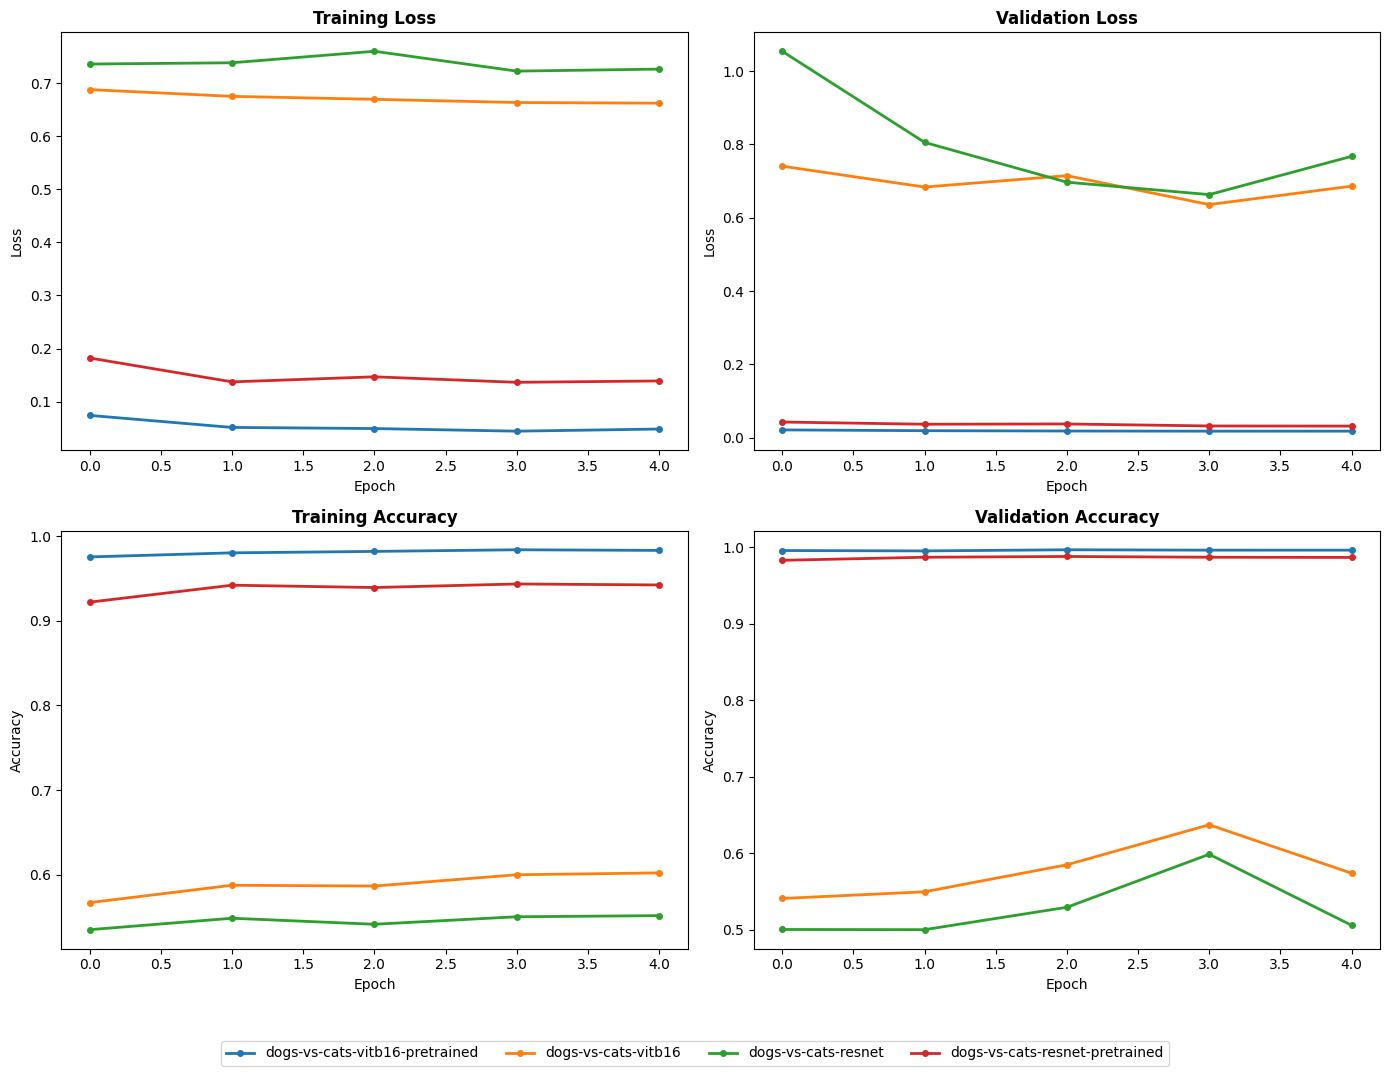

In [35]:
import json
import os
from PIL import Image
import matplotlib.pyplot as plt

logs_dir = './logs'

experiments = {}
if os.path.exists(logs_dir):
    for exp_name in os.listdir(logs_dir):
        exp_path = os.path.join(logs_dir, exp_name)
        history_file = os.path.join(exp_path, 'history.json')

        if os.path.exists(history_file):
            with open(history_file, 'r') as f:
                history = json.load(f)
                experiments[exp_name] = history

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

metrics = [
    ('train_loss', 'Training Loss', 'Loss', axes[0, 0]),
    ('val_loss', 'Validation Loss', 'Loss', axes[0, 1]),
    ('train_accuracy', 'Training Accuracy', 'Accuracy', axes[1, 0]),
    ('val_accuracy', 'Validation Accuracy', 'Accuracy', axes[1, 1])
]

for key, title, ylabel, ax in metrics:
    for exp_name, history in experiments.items():
        ax.plot(history['epochs'], history[key], label=exp_name, linewidth=2, marker='o', markersize=4)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.02),
           ncol=len(experiments), fontsize=10, frameon=True)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

*ROC Curve of Best Model*

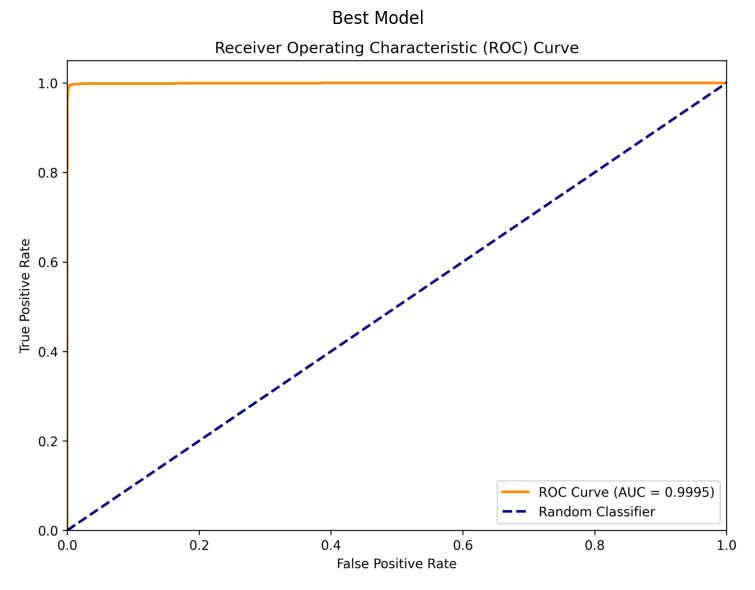

In [39]:
img_path = 'result/dogs-vs-cats-vitb16-pretrained/roc_curve.png'

img = Image.open(img_path)
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis('off')
plt.title('Best Model')
plt.tight_layout()
plt.show()

*Confusion matrices*

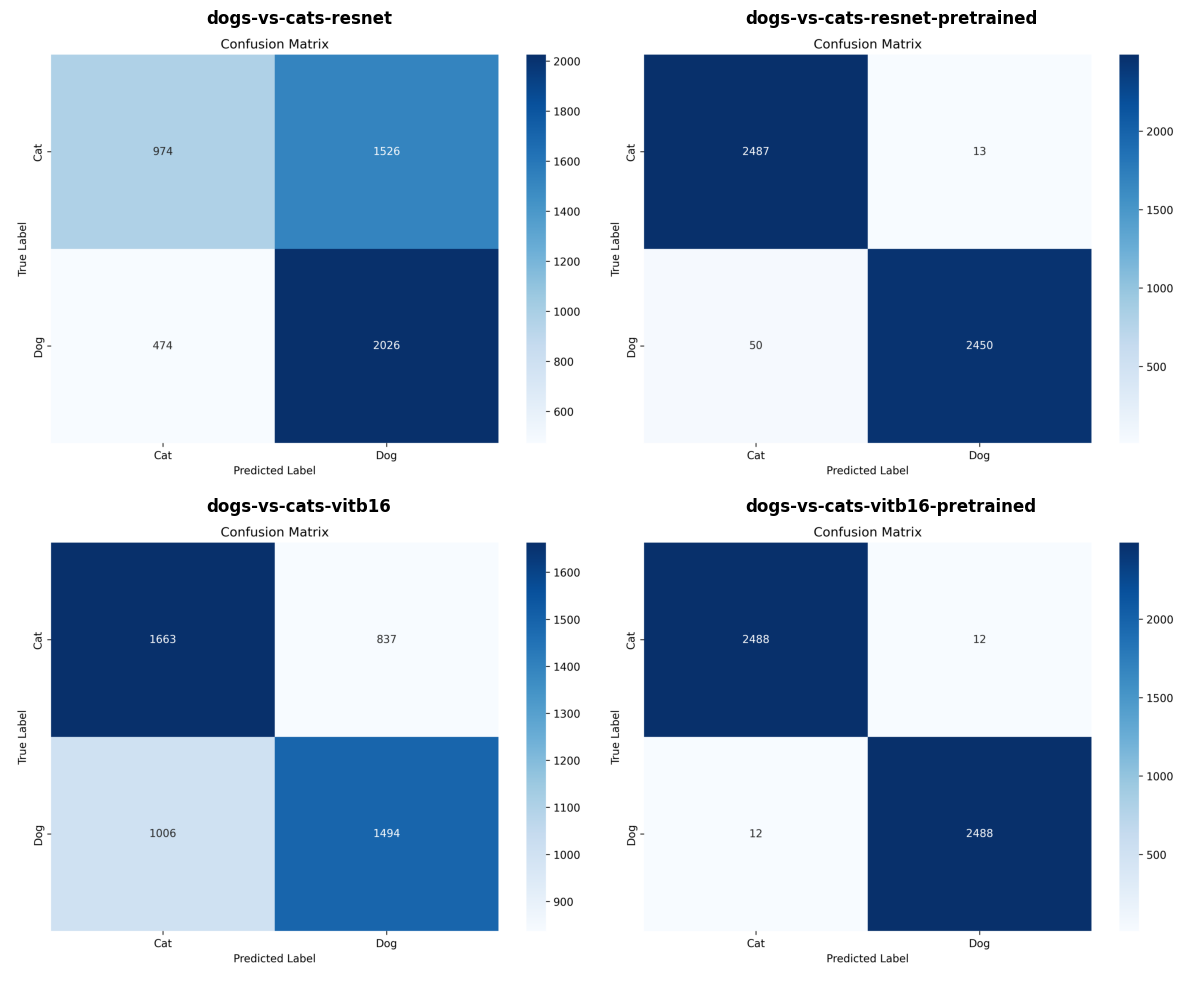

In [42]:
result_dir = './result'

# Collect all experiment folders
experiments = sorted([d for d in os.listdir(result_dir)
                    if os.path.isdir(os.path.join(result_dir, d))])

# Create 2x2 grid
num_exps = len(experiments)
rows = (num_exps + 1) // 2
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 5*rows))

# Handle single subplot case
if num_exps == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Plot confusion matrices
for idx, exp_name in enumerate(experiments):
    ax = axes[idx]
    exp_path = os.path.join(result_dir, exp_name)
    cm_path = os.path.join(exp_path, 'confusion_matrix.png')

    if os.path.exists(cm_path):
        img = Image.open(cm_path)
        ax.imshow(img)
        ax.set_title(exp_name, fontsize=12, fontweight='bold')
    else:
        ax.text(0.5, 0.5, f'{exp_name}\n(Not found)',
                ha='center', va='center', fontsize=10)

    ax.axis('off')

# Hide unused subplots
for idx in range(len(experiments), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()